# Exploratory Data Analysis - German Credit Dataset

**Project:** Federated Learning for Credit Risk Assessment  
**Author:** [Suyash Madke]  
**Date:** February 2026

---

## Objectives

1. Load and understand the German Credit Dataset
2. Analyze feature distributions and relationships
3. Identify data quality issues
4. Explore class imbalance
5. Generate insights for preprocessing

---

## 1. Setup and Imports

In [51]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configure
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

print("✓ Imports successful!")
print(f"✓ Project root: {PROJECT_ROOT}")

✓ Imports successful!
✓ Project root: C:\Users\adity\Downloads\federated_credit_risk


## 2. Load Dataset

In [52]:
# Import custom loader
import sys
sys.path.append(str(PROJECT_ROOT))
from utils.data_loader import load_german_credit_data, print_dataset_info

# Load data
df = load_german_credit_data()

if df is not None:
    print("✓ Dataset loaded successfully!")
    print_dataset_info(df)
else:
    print("✗ Failed to load dataset")

Loading existing dataset from C:\Users\adity\Downloads\federated_credit_risk\data\raw\german_credit_raw.data
✓ Dataset loaded successfully!

GERMAN CREDIT DATASET INFORMATION

📊 Shape: 1000 rows × 21 columns

📋 Columns (21):
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_rate', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']

🎯 Target Variable Distribution:
class
1    700
2    300
Name: count, dtype: int64
   - Class 1 (Good): 700 (70.0%)
   - Class 2 (Bad):  300 (30.0%)

📈 Numerical Features:
   - duration: range [4, 72]
   - credit_amount: range [250, 18424]
   - installment_rate: range [1, 4]
   - residence_since: range [1, 4]
   - age: range [19, 75]
   - existing_credits: range [1, 4]
   - num_dependents: range [1, 2]

📝 Categorical Features:
   - ch

## 3. Basic Dataset Overview

In [53]:
# Display first few rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2
5,A14,36,A32,A46,9055,A65,A73,2,A93,A101,4,A124,35,A143,A153,1,A172,2,A192,A201,1
6,A14,24,A32,A42,2835,A63,A75,3,A93,A101,4,A122,53,A143,A152,1,A173,1,A191,A201,1
7,A12,36,A32,A41,6948,A61,A73,2,A93,A101,2,A123,35,A143,A151,1,A174,1,A192,A201,1
8,A14,12,A32,A43,3059,A64,A74,2,A91,A101,4,A121,61,A143,A152,1,A172,1,A191,A201,1
9,A12,30,A34,A40,5234,A61,A71,4,A94,A101,2,A123,28,A143,A152,2,A174,1,A191,A201,2


In [54]:
# Dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1} (+ 1 target)")

Dataset shape: (1000, 21)
Number of samples: 1000
Number of features: 20 (+ 1 target)


In [55]:
# Data types
print("\nData types:")
df.dtypes


Data types:


checking_status          str
duration               int64
credit_history           str
purpose                  str
credit_amount          int64
savings_status           str
employment               str
installment_rate       int64
personal_status          str
other_parties            str
residence_since        int64
property_magnitude       str
age                    int64
other_payment_plans      str
housing                  str
existing_credits       int64
job                      str
num_dependents         int64
own_telephone            str
foreign_worker           str
class                  int64
dtype: object

In [56]:
# Statistical summary for numerical features
print("\nNumerical features summary:")
df.describe()


Numerical features summary:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


## 4. Target Variable Analysis

In [57]:
# Class distribution
print("Target variable distribution:")
print(df['class'].value_counts())
print("\nPercentage:")
print(df['class'].value_counts(normalize=True) * 100)

Target variable distribution:
class
1    700
2    300
Name: count, dtype: int64

Percentage:
class
1    70.0
2    30.0
Name: proportion, dtype: float64


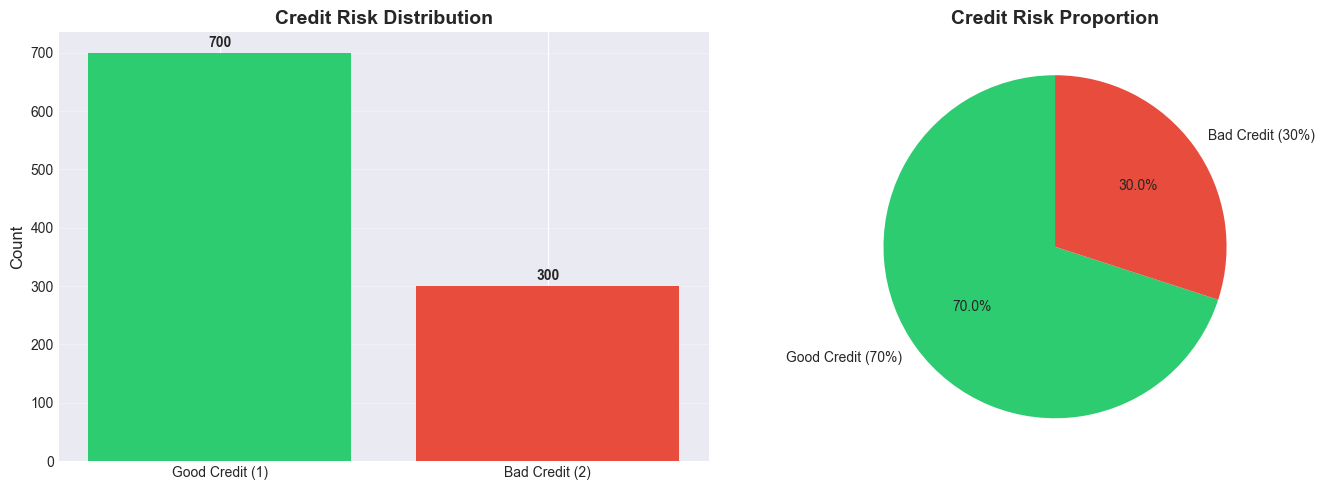


⚠️ Class imbalance ratio: 2.33:1
Note: This moderate imbalance should be addressed during modeling.


In [58]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
class_counts = df['class'].value_counts().sort_index()
axes[0].bar(['Good Credit (1)', 'Bad Credit (2)'], class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Credit Risk Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts.values, labels=['Good Credit (70%)', 'Bad Credit (30%)'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Credit Risk Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Class imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n⚠️ Class imbalance ratio: {imbalance_ratio:.2f}:1")
print("Note: This moderate imbalance should be addressed during modeling.")

## 5. Numerical Features Analysis

In [59]:
# Identify numerical features
numerical_features = ['duration', 'credit_amount', 'installment_rate', 
                     'residence_since', 'age', 'existing_credits', 'num_dependents']

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

Numerical features (7): ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


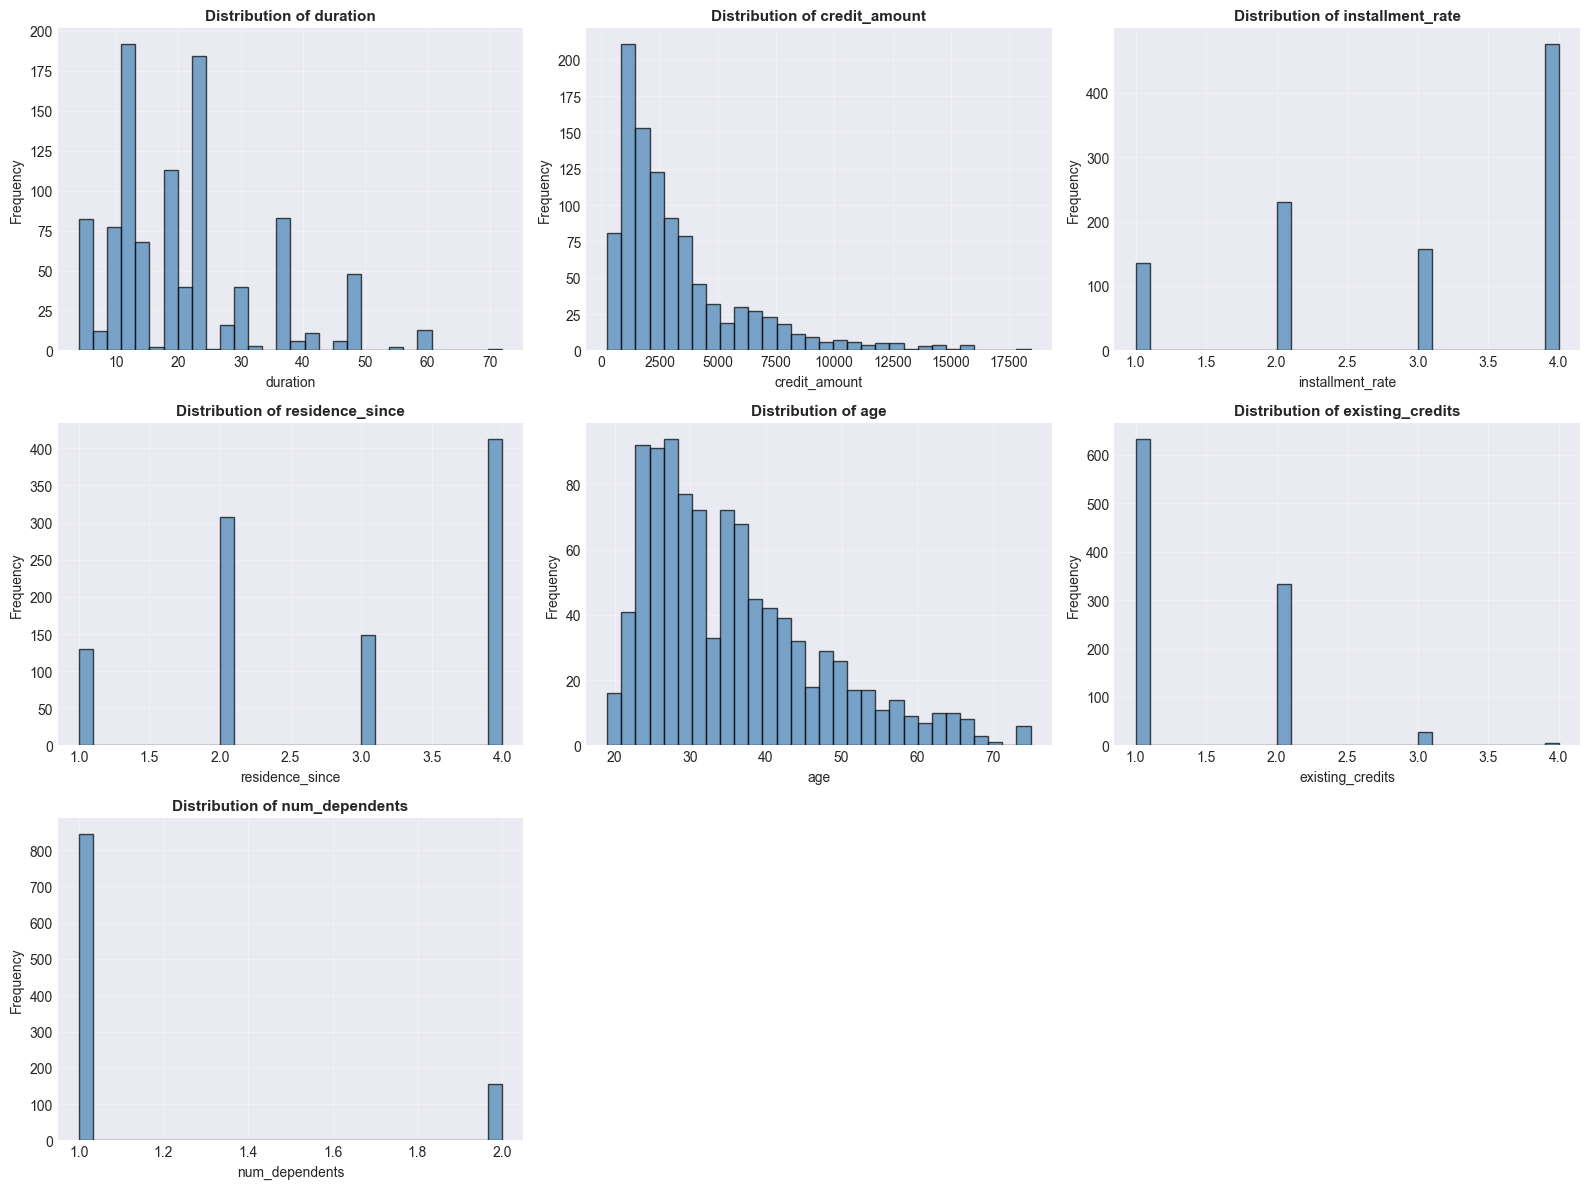

In [60]:
# Distribution plots for numerical features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3)

# Remove extra subplots
for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

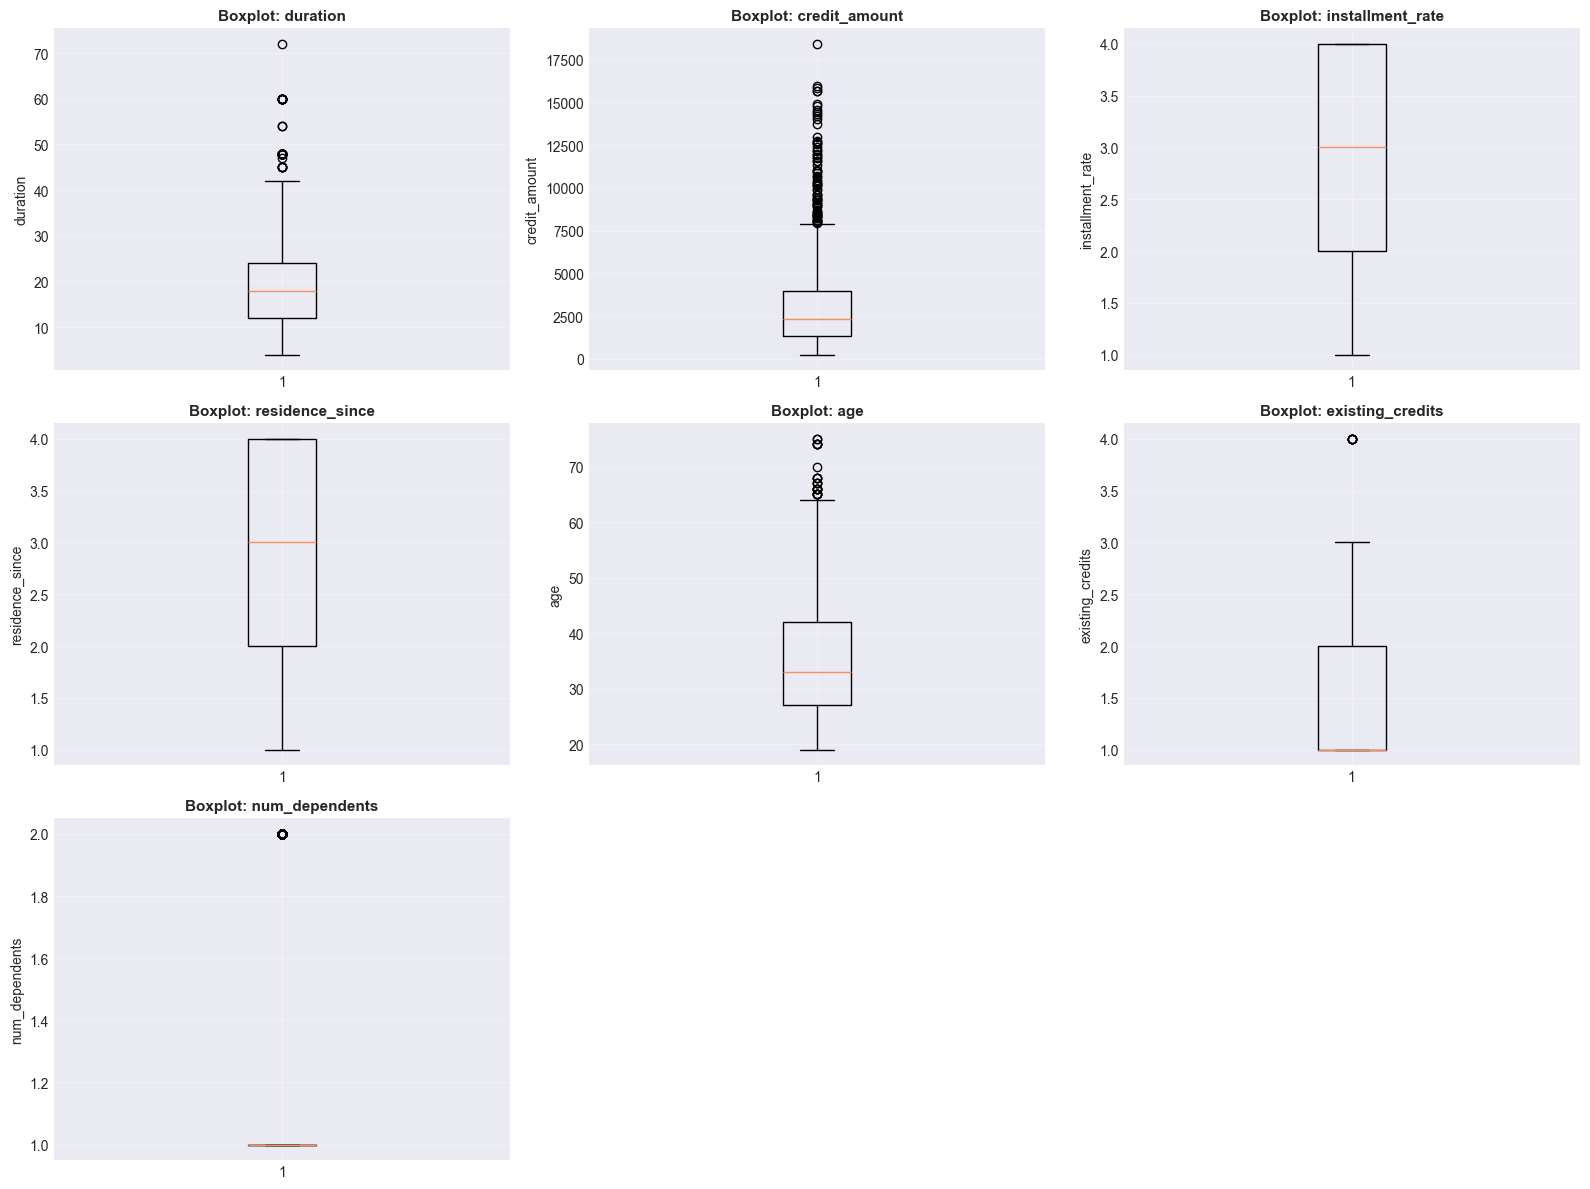

In [61]:
# Box plots to detect outliers
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3)

for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

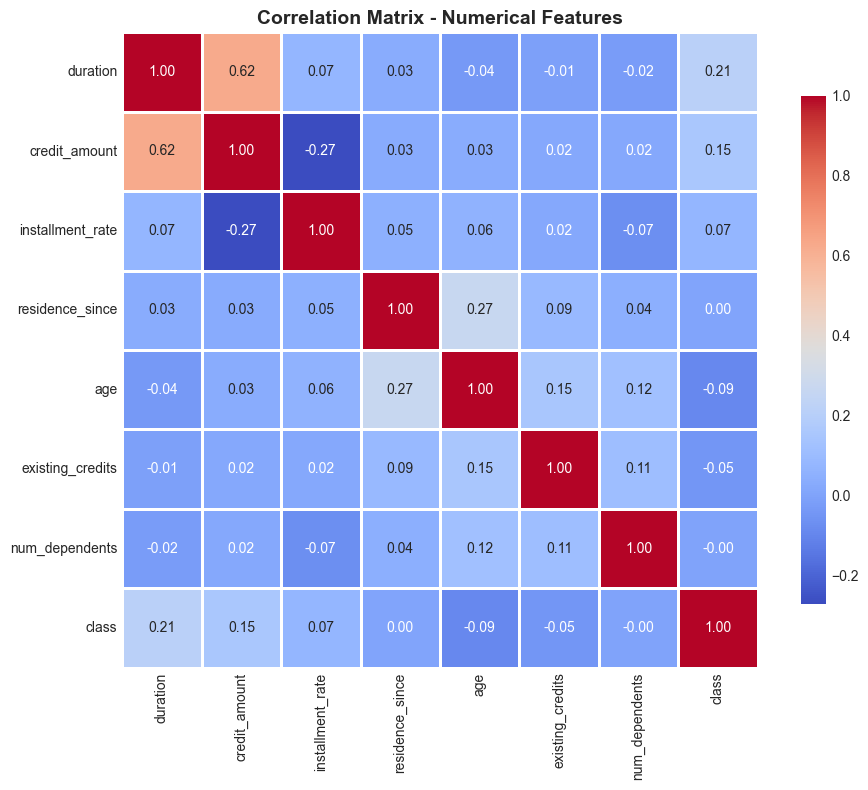


📊 Key Correlations with Target Variable:
duration            0.214927
credit_amount       0.154739
installment_rate    0.072404
residence_since     0.002967
num_dependents     -0.003015
existing_credits   -0.045732
age                -0.091127
Name: class, dtype: float64


In [62]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_features + ['class']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Key Correlations with Target Variable:")
target_corr = correlation_matrix['class'].sort_values(ascending=False)
print(target_corr[target_corr.index != 'class'])

## 6. Categorical Features Analysis

In [63]:
# Identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features ({len(categorical_features)}):")
for col in categorical_features:
    print(f"  - {col}: {df[col].nunique()} unique values")

Categorical features (13):
  - checking_status: 4 unique values
  - credit_history: 5 unique values
  - purpose: 10 unique values
  - savings_status: 5 unique values
  - employment: 5 unique values
  - personal_status: 4 unique values
  - other_parties: 3 unique values
  - property_magnitude: 4 unique values
  - other_payment_plans: 3 unique values
  - housing: 3 unique values
  - job: 4 unique values
  - own_telephone: 2 unique values
  - foreign_worker: 2 unique values


In [64]:
# Value counts for categorical features
for col in categorical_features[:5]:  # First 5 categorical features
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 50)


checking_status:
checking_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64
--------------------------------------------------

credit_history:
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64
--------------------------------------------------

purpose:
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64
--------------------------------------------------

savings_status:
savings_status
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64
--------------------------------------------------

employment:
employment
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64
--------------------------------------------------


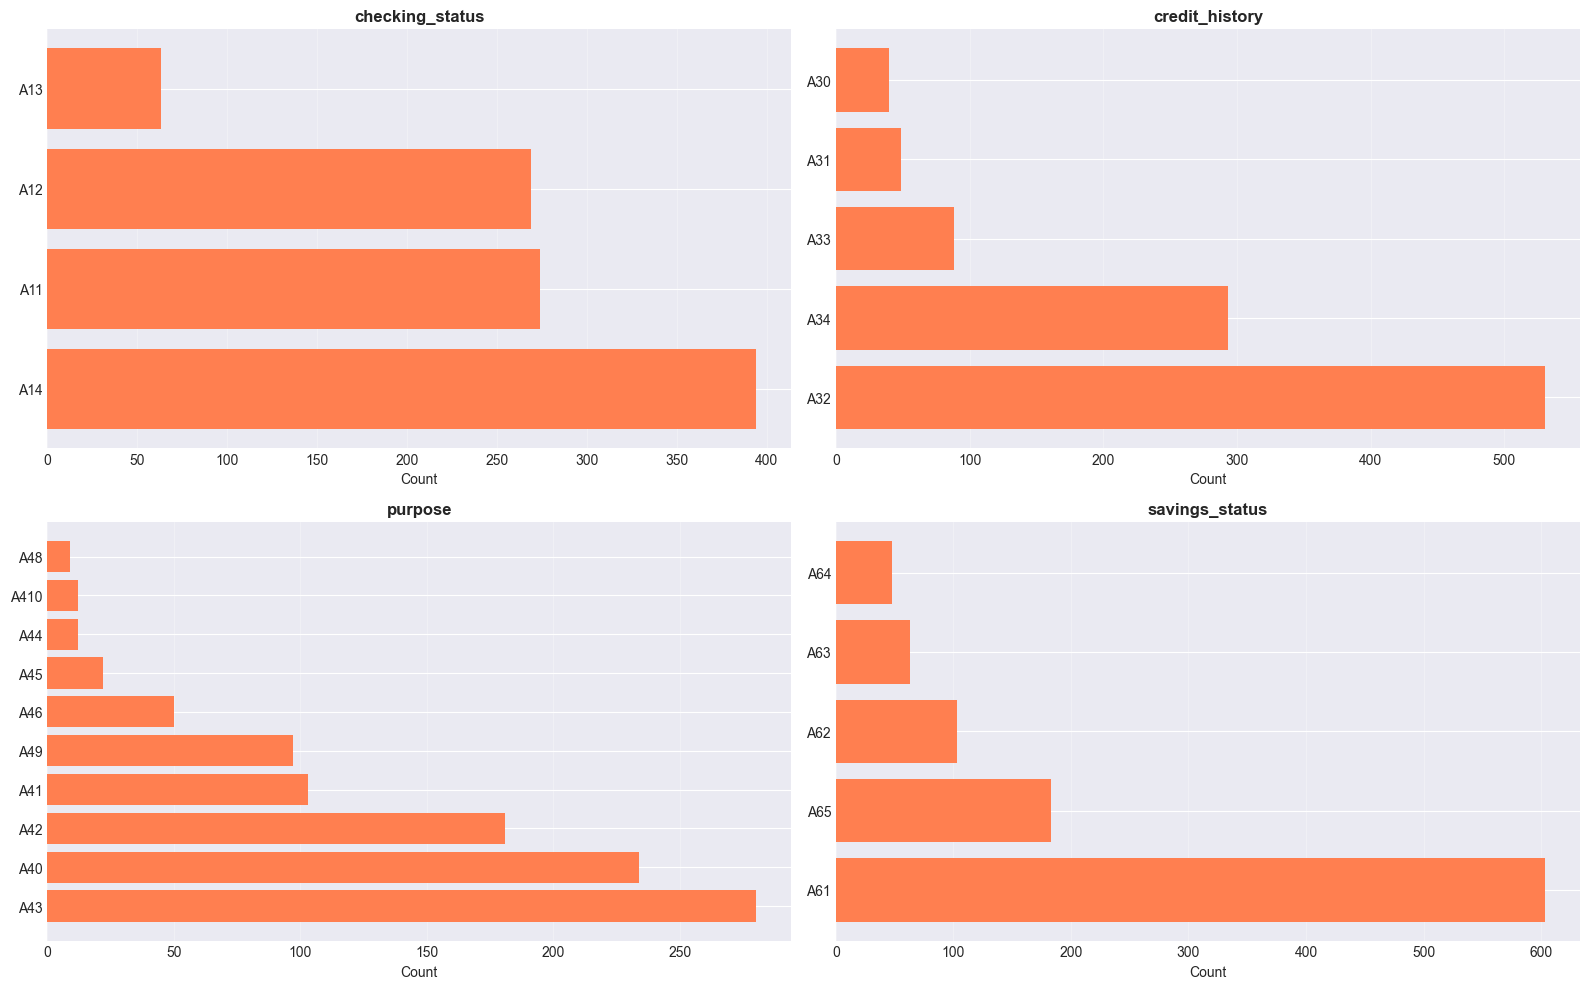

In [65]:
# Visualize top categorical features
top_categorical = ['checking_status', 'credit_history', 'purpose', 'savings_status']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(top_categorical):
    value_counts = df[col].value_counts()
    axes[idx].barh(range(len(value_counts)), value_counts.values, color='coral')
    axes[idx].set_yticks(range(len(value_counts)))
    axes[idx].set_yticklabels(value_counts.index)
    axes[idx].set_xlabel('Count', fontsize=10)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature vs Target Analysis

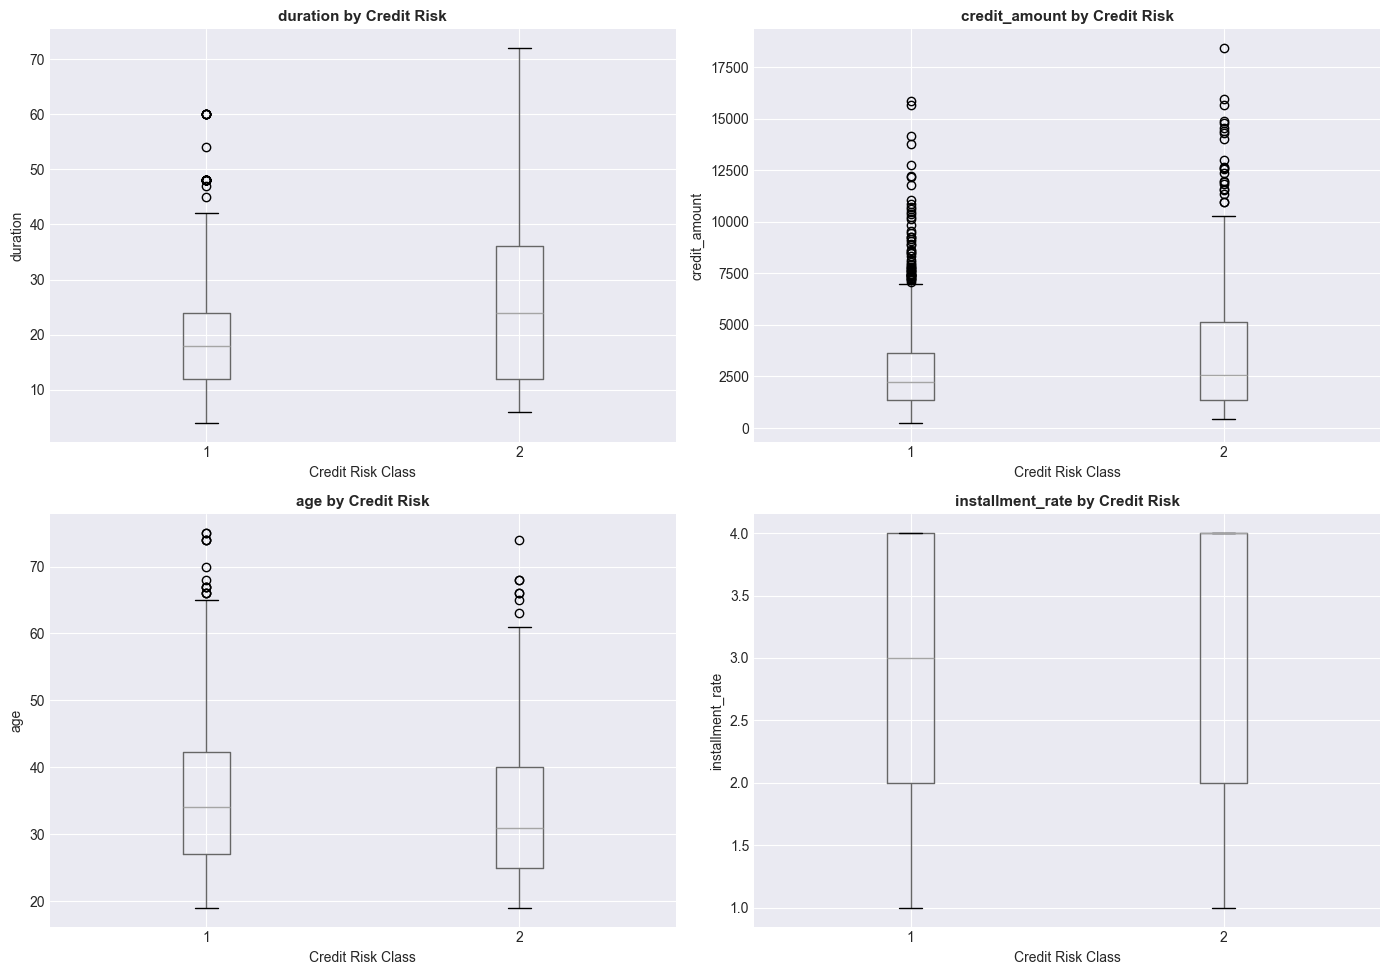

In [66]:
# Numerical features vs target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

key_numerical = ['duration', 'credit_amount', 'age', 'installment_rate']

for idx, col in enumerate(key_numerical):
    df.boxplot(column=col, by='class', ax=axes[idx])
    axes[idx].set_xlabel('Credit Risk Class', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_title(f'{col} by Credit Risk', fontsize=11, fontweight='bold')
    axes[idx].get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

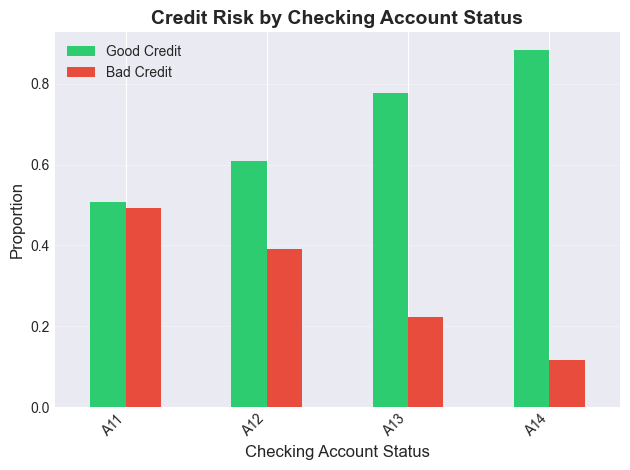

In [67]:
# Categorical features vs target (example: checking_status)
plt.figure(figsize=(12, 6))
pd.crosstab(df['checking_status'], df['class'], normalize='index').plot(
    kind='bar', stacked=False, color=['#2ecc71', '#e74c3c']
)
plt.xlabel('Checking Account Status', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Credit Risk by Checking Account Status', fontsize=14, fontweight='bold')
plt.legend(['Good Credit', 'Bad Credit'])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Data Quality Assessment

In [68]:
# Missing values
print("Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])

Missing Values:
✓ No missing values found!


In [69]:
# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates == 0:
    print("✓ No duplicate rows found!")


Duplicate rows: 0
✓ No duplicate rows found!


In [70]:
# Cardinality check for categorical features
print("\nCardinality of categorical features:")
for col in categorical_features:
    n_unique = df[col].nunique()
    print(f"  {col}: {n_unique} unique values")


Cardinality of categorical features:
  checking_status: 4 unique values
  credit_history: 5 unique values
  purpose: 10 unique values
  savings_status: 5 unique values
  employment: 5 unique values
  personal_status: 4 unique values
  other_parties: 3 unique values
  property_magnitude: 4 unique values
  other_payment_plans: 3 unique values
  housing: 3 unique values
  job: 4 unique values
  own_telephone: 2 unique values
  foreign_worker: 2 unique values


## 9. Key Insights and Recommendations

In [71]:
print("="*70)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features: {len(numerical_features)} numerical, {len(categorical_features)} categorical")
print(f"   - No missing values ✓")
print(f"   - No duplicate rows ✓")

print("\n2. TARGET VARIABLE:")
good_pct = (df['class'] == 1).sum() / len(df) * 100
bad_pct = (df['class'] == 2).sum() / len(df) * 100
print(f"   - Good credit: {good_pct:.1f}%")
print(f"   - Bad credit: {bad_pct:.1f}%")
print(f"   - Imbalance ratio: {imbalance_ratio:.2f}:1")
print("   ⚠️ Moderate class imbalance - consider SMOTE or class weights")

print("\n3. NUMERICAL FEATURES:")
print("   - 'credit_amount' has wide range (250-18,424 DM) → needs scaling")
print("   - 'duration' shows some outliers → consider capping")
print("   - 'age' ranges from 19-75 years")

print("\n4. CATEGORICAL FEATURES:")
print("   - Most features have 3-5 categories")
print("   - 'purpose' has 11 categories → may need grouping")
print("   - All use coded values (A11, A12, etc.) → needs label mapping")

print("\n5. FEATURE IMPORTANCE INDICATORS:")
print("   - 'checking_status' shows strong relationship with target")
print("   - 'duration' and 'credit_amount' correlate with risk")
print("   - 'credit_history' appears to be a key predictor")

print("\n6. PREPROCESSING RECOMMENDATIONS:")
print("   ✓ Encode categorical variables (One-Hot or Label Encoding)")
print("   ✓ Scale numerical features (StandardScaler or MinMaxScaler)")
print("   ✓ Handle class imbalance (SMOTE or class weights)")
print("   ✓ Consider feature engineering (e.g., debt-to-income ratio)")
print("   ✓ Split data maintaining class distribution (stratified split)")

print("\n7. FEDERATED LEARNING SETUP:")
print("   - Dataset size (1000) suitable for 3-5 federated clients")
print("   - Can simulate IID: random split")
print("   - Can simulate Non-IID: split by categorical features")
print("   - Recommend 70-30 train-test split per client")

print("\n" + "="*70)
print("NEXT STEPS: Proceed to data preprocessing and feature engineering")
print("="*70)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. DATASET CHARACTERISTICS:
   - Total samples: 1000
   - Features: 7 numerical, 13 categorical
   - No missing values ✓
   - No duplicate rows ✓

2. TARGET VARIABLE:
   - Good credit: 70.0%
   - Bad credit: 30.0%
   - Imbalance ratio: 2.33:1
   ⚠️ Moderate class imbalance - consider SMOTE or class weights

3. NUMERICAL FEATURES:
   - 'credit_amount' has wide range (250-18,424 DM) → needs scaling
   - 'duration' shows some outliers → consider capping
   - 'age' ranges from 19-75 years

4. CATEGORICAL FEATURES:
   - Most features have 3-5 categories
   - 'purpose' has 11 categories → may need grouping
   - All use coded values (A11, A12, etc.) → needs label mapping

5. FEATURE IMPORTANCE INDICATORS:
   - 'checking_status' shows strong relationship with target
   - 'duration' and 'credit_amount' correlate with risk
   - 'credit_history' appears to be a key predictor

6. PREPROCESSING RECOMMENDATIONS:
   ✓ Encode categorical variables (One-Hot 

## 10. Save Summary Statistics

In [72]:
# Save summary to file for documentation
summary_stats = df.describe(include='all').T
summary_path = PROJECT_ROOT / 'results' / 'eda_summary_statistics.csv'
summary_stats.to_csv(summary_path)
print(f"✓ Summary statistics saved to: {summary_path}")

✓ Summary statistics saved to: C:\Users\adity\Downloads\federated_credit_risk\results\eda_summary_statistics.csv


---

## Conclusion

This EDA has provided comprehensive insights into the German Credit Dataset:

- **Dataset is clean** with no missing values or duplicates
- **Moderate class imbalance** exists (70-30 split)
- **Mix of numerical and categorical features** requiring different preprocessing
- **Several features show strong relationship** with credit risk
- **Dataset is suitable** for federated learning simulation

**Next:** Proceed to `02_preprocessing.ipynb` for data cleaning and transformation.

---